In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("steam_games_dataset.csv")

print(df.shape)
df.head()

(10000, 17)


,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819


In [3]:
df['High_CCU'] = (df['ccu'] > 50).astype(int)

In [4]:
print(df['High_CCU'].value_counts())

High_CCU
0    7613
1    2387
Name: count, dtype: int64


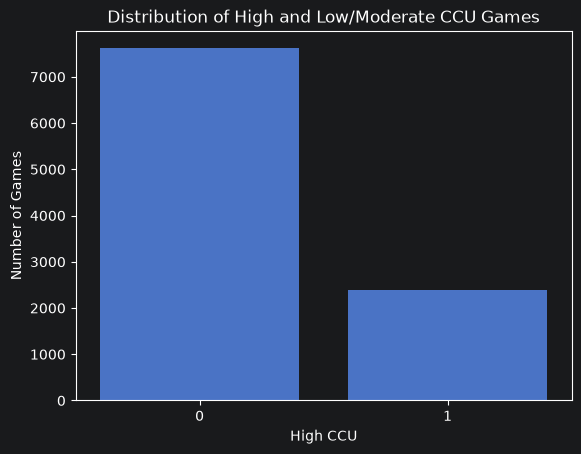

In [5]:
sns.countplot(x='High_CCU', data=df)

plt.xlabel("High CCU")
plt.ylabel("Number of Games")
plt.title("Distribution of High and Low/Moderate CCU Games")

plt.show()

In [6]:
features = [
    'positive',
    'negative',
    'userscore',
    'average_forever',
    'average_2weeks',
    'median_forever',
    'median_2weeks',
    'price',
    'initialprice',
    'discount'
]

X = df[features]
y = df['High_CCU']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]),

    "Naive Bayes": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ])
}

In [9]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    sensitivity = recall

    specificity = tn / (tn + fp)

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1
    })

In [10]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  Sensitivity  Specificity  F1 Score
      Random Forest    0.8905   0.743396 0.825996     0.825996     0.910703  0.782522
      Decision Tree    0.8925   0.814904 0.710692     0.710692     0.949442  0.759239
                KNN    0.8740   0.767221 0.677149     0.677149     0.935653  0.719376
Logistic Regression    0.8780   0.867508 0.576520     0.576520     0.972423  0.692695
        Naive Bayes    0.8510   0.848249 0.457023     0.457023     0.974393  0.594005


In [11]:
best_model_name = results_df.iloc[0]["Model"]

best_f1 = results_df.iloc[0]["F1 Score"]

print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1)

Best Model: Random Forest
Best F1 Score: 0.7825223435948362


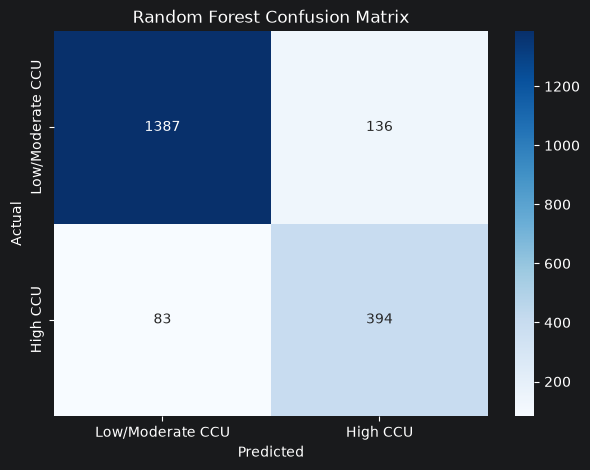

In [12]:
best_model = models["Random Forest"]

y_pred_rf = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low/Moderate CCU', 'High CCU'],
    yticklabels=['Low/Moderate CCU', 'High CCU']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

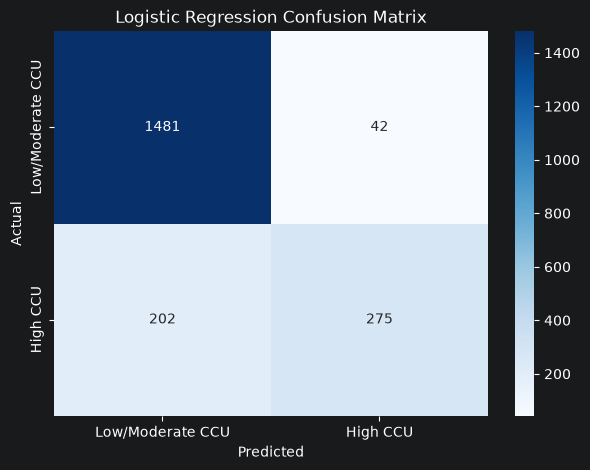

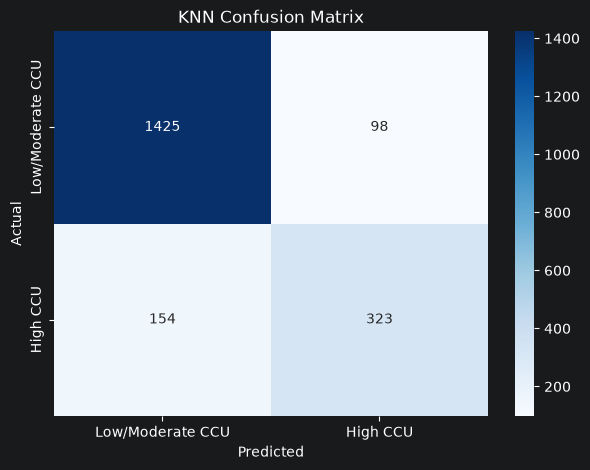

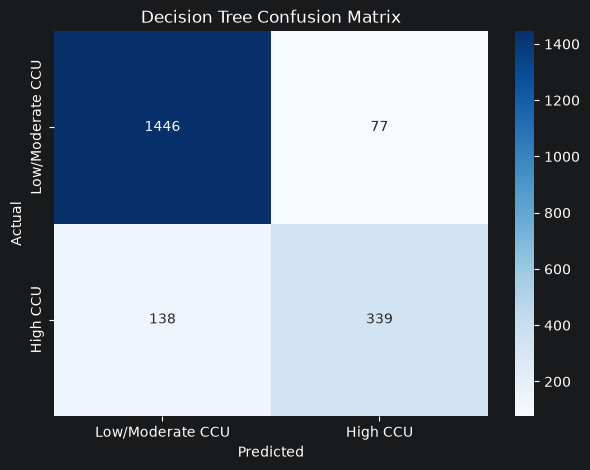

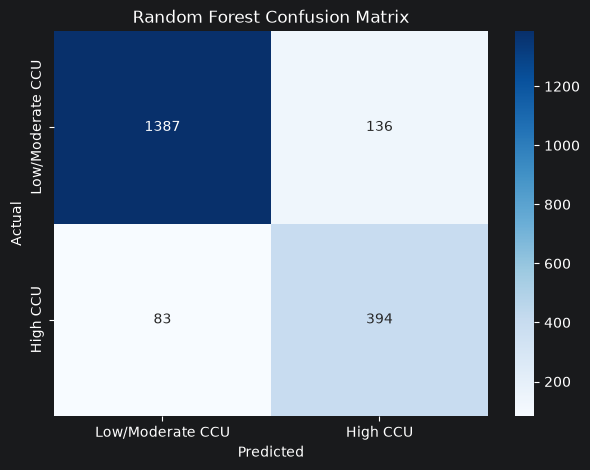

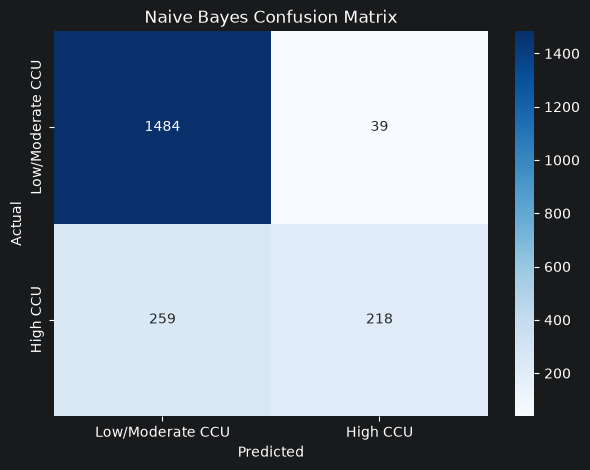

In [13]:
#Confusion matrix of all models
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm=confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Low/Moderate CCU', 'High CCU'],
        yticklabels=['Low/Moderate CCU', 'High CCU']
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name+" Confusion Matrix")


In [14]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Low/Moderate CCU",
            "High CCU"
        ]
    )
)

                  precision    recall  f1-score   support

Low/Moderate CCU       0.94      0.91      0.93      1523
        High CCU       0.74      0.83      0.78       477

        accuracy                           0.89      2000
       macro avg       0.84      0.87      0.85      2000
    weighted avg       0.90      0.89      0.89      2000



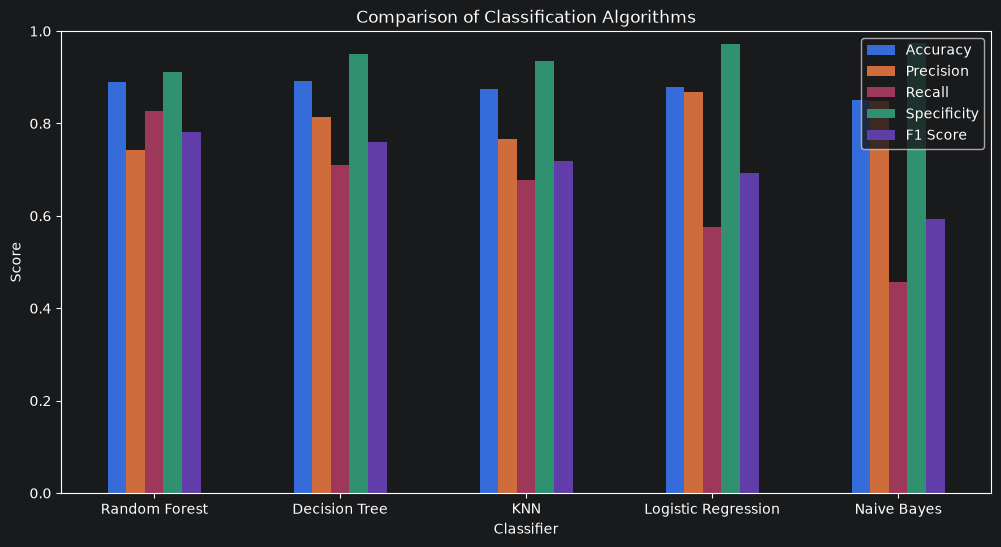

In [15]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1 Score"
]

plot_df = results_df.set_index("Model")[metrics]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Score")
plt.xlabel("Classifier")
plt.title("Comparison of Classification Algorithms")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()

plt.show()